# HULL-WHITE AND EIOPA RISK-FREE CURVE: MARKET CONSISTENCY AND DISTRIBUTION CHECK
<a id="0"></a> <br>
The Hull-White model (HW) is a very popular choice when modelling interest rates. For example, economic scenario generators use the HW model to simulate risk-free rates. This notebook validates the HW implementation in `src/hull_white.py`. The first section uses the EIOPA Risk-Free-Rate (RFR) calibration to produce a term structure. In the second section, this term structure is used to produce a number of stochastic interest rate scenarios. The remaining sections check that the term structure is reproduced correctly, that the scenarios are market consistent, that the simulated distribution matches the closed-form distribution of the model, and that the scenarios reproduce closed-form prices of bonds and bond options.

HW model is presented in two different forms in literature. This script starts from the following differential equation:

$$ dr(t) = \big( \theta(t) - a r(t) \big) dt + \sigma dW(t) $$

Where:
 - t is time.
 - r(t) is the short rate at time t.
 - $\theta (t)$ is the time-dependent parameter theta.
 - a is the mean reversion speed parameter.
 - $\sigma$ is the volatility parameter.
 - $W(t)$ is a standard Brownian motion.

The parameter $\theta(t)$ is calibrated to the term structure with the relation:

$$ \theta(t) =  \frac{\partial f(0,t)}{\partial t} + a f(0,t) + \frac{\sigma^2}{2 a}\big( 1 - e^{-2 a t} \big) $$

Where $f(0,t)$ is the instantaneous forward rate at time t, implied by the price of a zero-coupon bond (ZCB) $P(0,t)$ issued at time 0 with maturity t and a notional amount of 1.

### Exact simulation scheme

With this choice of $\theta(t)$, the short rate can be written as a deterministic part plus a stochastic part:

$$ r(t) = \alpha(t) + x(t), \qquad \alpha(t) = f(0,t) + \frac{\sigma^2}{2a^2}\big(1 - e^{-at}\big)^2, \qquad dx(t) = -a x(t) dt + \sigma dW(t), \quad x(0) = 0 $$

The implementation simulates $x(t)$ and its integral $Y(t) = \int_0^t x(s) ds$ exactly on the time grid $t_0 = 0 < t_1 < \dots < t_N = T$. Given $x(t_{i-1})$, the pair $\big(x(t_i), Y(t_i) - Y(t_{i-1})\big)$ is normally distributed with known mean and covariance, and is sampled with two independent standard normal draws. The discount factor is:

$$ D(t) = e^{-\int_0^t r(s) ds} = P(0,t) \exp\Big( -\frac{1}{2} V(t) - Y(t) \Big), \qquad V(t) = \frac{\sigma^2}{a^2}\Big( t - \frac{2}{a}\big(1 - e^{-at}\big) + \frac{1}{2a}\big(1 - e^{-2at}\big) \Big) $$

Where $V(t)$ is the variance of $Y(t)$. The scheme has no discretisation error for any time step (see P. Glasserman (2003), *Monte Carlo Methods in Financial Engineering*, Springer, section 3.3 "Gaussian Short Rate Models". See also V. Ostrovski (2013), *Efficient and Exact Simulation of the Hull-White Model*, SSRN 2304848).

### Summary

The goal of this script is to answer the following questions:
 - Does the term structure used by the generator reproduce the curve published by EIOPA?
 - Is the HW simulation correctly implemented?
 - Are the simulated scenarios market consistent (do the average discount factors reproduce the term structure)?
 - Does the simulated distribution of the short rate match the closed-form distribution implied by the parameters?
 - Do the scenarios reproduce the closed-form prices of bonds and bond options?
 - Is the number of scenarios sufficiently large?

# Table of Contents
1. [Note on Smith & Wilson algorithm](#1)
2. [Success criteria](#2)
3. [Data requirements](#3)
4. [Hull-White parameters](#4)
5. [External dependencies](#5)
6. [Importing data](#6)
7. [Hull-White simulation](#7)
8. [Test 1; Term structure compared to the EIOPA published curve](#8)
9. [Test 2; Deterministic checks](#9)
10. [Test 3; Martingale test](#10)
11. [Test 4; Distribution of the short rate](#11)
12. [Test 5; Prices of bonds and bond options](#12)
13. [Number of scenarios](#13)
14. [Conclusion](#14)

<a id="1"></a> <br>
## Note on Smith & Wilson algorithm

The validation of RFR rate is performed in another script that checks the correct calibration of the EIOPA's RFR output, also available on OSM Github as a [Jupyter notebook](https://github.com/open-source-modelling/insurance_jupyter/tree/main/enough_stochastic_scenarios).

This example uses a modified Smith&Wilson implementation (The original implementation is availible on [GitHub](https://github.com/open-source-modelling):
-  [Python](https://github.com/open-source-modelling/insurance_python/tree/main/smith%26wilson)
-  [Matlab](https://github.com/open-source-modelling/insurance_matlab/tree/main/smith%26wilson)
-  [JavaScript](https://github.com/open-source-modelling/insurance_javascript/tree/main/smith-wilson)

#### Limitations of the implementation
The instantaneous forward rate $f(0,t)$ is approximated with a centered finite difference with step `epsilon`. The script simplifies the day-count convention with the assumption that each month represents 1/12-th of a year. At every time step, the normal draws are rescaled to have a sample mean of 0 and a sample standard deviation of 1 (moment matching). This reduces the Monte Carlo noise, but it also means that some statistics (for example the mean of the short rate) are reproduced exactly by construction.

Only a single EIOPA curve is used (No volatility adjustment).

<a id="2"></a> <br>
## Success criteria

The following success criteria is defined:
-  Test 1: Maximum difference between the Smith & Wilson spot rates and the EIOPA published spot rates is less than 0.1 bps and the average difference is less than 0.05 bps.
-  Test 2: With $\sigma = 0$, the short rate is equal to the forward rate $f(0,t)$ and the discount factors are equal to the input term structure. For any $\sigma$, the index is equal to the inverse of the discount factor. All up to numerical precision.
-  Test 3: The average discount factor does not differ from $P(0,t)$ by more than the Monte Carlo noise. The maximum absolute z-score over all time steps is less than 4.5 and the average absolute z-score is less than 2.5.
-  Test 4: The mean of the short rate equals $\alpha(t)$ up to numerical precision. For the variance, the maximum absolute z-score over all time steps is less than 4.5 and the average absolute z-score is less than 2.5.
-  Test 5: The Monte Carlo prices of future zero-coupon bonds and of zero-coupon bond options do not differ from the closed-form prices by more than the Monte Carlo noise. The maximum absolute z-score is less than 4.5 and the average absolute z-score is less than 2.5.

The z-score thresholds were chosen by running Tests 3 to 5 with 200 different random seeds (10000 paths, 600 steps, the parameters of this run). All 200 runs passed.

The tests complement each other. With the same seed:
 - The previous implementation with the Euler scheme fails Test 2 (maximum difference between the discount factors and the term structure of 3.1e-4) and the mean check in Test 4 (difference of 4.2e-4).
 - A volatility 5% higher than the parameter fails Test 4 (maximum z-score 8.5 for the variance).
 - A short rate that is 5 bps too high while the discount factors are correct fails Test 5 (maximum z-score 6.0 for the bond prices). Test 3 does not detect this error, because it only looks at the discount factors.

In [1]:
term_structure_max_diff_in_bps = 0.1
term_structure_average_diff_in_bps = 0.05
numerical_precision = 1e-10
z_score_max = 4.5
z_score_average = 2.5

The success function that is called at the end of every check is the following (With the threasholds that are defined above).

In [2]:
def success_test(TestStatistics, threshold_max, threshold_mean):
    out1 = False
    out2 = False
    if np.max(TestStatistics)<threshold_max:
        print("Test passed")
        out1 = True
    else:
        print("Test failed")

    if np.mean(TestStatistics)<threshold_mean:
        print("Test passed")
        out2 = True
    else:
        print("Test failed")
    return [out1, out2]

This implementation looks at two kinds of test statistics. The average deviation and the maximum deviation.

The average deviation is defined as:

<font size=4>
$$S_{AVERAGE} = \frac{1}{N} \sum_{t = 0}^T \left|x_{THEORETICAL}(t) - x_{EST}(t) \right|$$
</font> <br>

The maximum deviation is defined as:
<font size=4>
$$ S_{MAX} = \max_t \left| x_{THEORETICAL}(t) - x_{EST}(t) \right| $$
</font> <br>

Where `N` is the number of time increments and `T` is the maximum maturity.

For the Monte Carlo estimates in Tests 3 to 5, the deviation is expressed as a z-score, which is the deviation divided by the standard error of the estimate:

<font size=4>
$$ z(t) = \frac{x_{EST}(t) - x_{THEORETICAL}(t)}{SE(t)} $$
</font> <br>

Using the z-score takes into account that the Monte Carlo noise grows with the time horizon.

<a id="3"></a> <br>
## Data requirements

This script uses the EIOPA RFR publication stored in the folder `data`. The publication can be found on the [EIOPA RFR website](https://www.eiopa.europa.eu/tools-and-data/risk-free-interest-rate-term-structures_en).

 - `data/Param_no_VA.csv` contains, for each country, the observed maturities, the Smith & Wilson calibration vector and the additional parameters (`UFR` and `alpha`). It corresponds to the sheet *SW_Qb_no_VA* in the EIOPA workbook *EIOPA_RFR_YYYYMMDD_Qb_SW.xlsx*.
 - `data/Curves_no_VA.csv` contains the published spot rates for maturities 1 to 150 years. It corresponds to the sheet *RFR_spot_no_VA* in the EIOPA workbook *EIOPA_RFR_YYYYMMDD_Term_Structures.xlsx*.

<a id="4"></a> <br>
## Hull-White parameters

This script provides validation for a single run of the Hull-White model. The run specifications are stored in `data/Parameters.csv`. The first cell also makes the model code in the folder `src` available to this notebook:

In [3]:
import os
import sys
import pandas as pd

# This notebook is stored in the folder "notebooks". The model code is in the folder "src"
# and the input files are in the folder "data". The root folder of the repository is the
# first folder, starting from the current one, that contains both. This works whether the
# notebook is started from the folder "notebooks" or from the root folder.
repository_root = os.path.abspath(".")
while not (os.path.isdir(os.path.join(repository_root, "src")) and os.path.isdir(os.path.join(repository_root, "data"))):
    parent_folder = os.path.dirname(repository_root)
    if parent_folder == repository_root:
        raise FileNotFoundError("Could not find the root folder of the repository (the folder with src and data)")
    repository_root = parent_folder
data_folder = os.path.join(repository_root, "data")
sys.path.insert(0, os.path.join(repository_root, "src"))

param_raw = pd.read_csv(os.path.join(data_folder, "Parameters.csv"), sep=',', index_col=0)
display(param_raw)

,model,Type,NoOfPaths,NoOfSteps,T,a,sigma,epsilon,Country,selected_param_file,selected_curves_file,mu,gamma
Calibration_ID,,,,,,,,,,,,,
11,HW,I,10000,600,50,0.05,0.008,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.00,0.0
22,BS,I,10000,600,50,0.00,0.200,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.00,0.0
33,V,D,10000,600,50,0.00,0.020,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.02,0.3


This script will look at the run with the calibration id that uses the Hull-White model:

In [4]:
calibration_id = 11

The random seed is fixed so that the results of this notebook are reproducible:

In [5]:
seed = 0

<a id="5"></a> <br>
## External dependencies

This script uses a set of well known Python packages that are commonly used in finance. Numpy for the mathematical operation and matrix multiplication, Pandas for its table manipulation functionality and Matplotlib for charts. The model itself is imported from the modules in this repository.

In [6]:
import math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from read_input import read_model_input
from term_structure import calculate_zero_coupon_price, smith_wilson_extrapolate_yield_curve, calculate_instantaneous_forward_rate
from hull_white import calculate_hull_white_paths

In [7]:
print(f"The Numpy version is {np.__version__}.")
print(f"The Pandas version is {pd.__version__}.")
print(f"The Matplotlib version is {mpl.__version__}.")

The Numpy version is 1.26.4.
The Pandas version is 2.2.2.
The Matplotlib version is 3.8.4.


<a id="6"></a> <br>
## Importing data

The run parameters and the Smith & Wilson calibration for the selected country are read with the same function that the generator uses (`read_model_input`).

In [8]:
[modeling_parameters, curve_parameters] = read_model_input(calibration_id)
param_raw.loc[calibration_id]

model                                 HW
Type                                   I
NoOfPaths                          10000
NoOfSteps                            600
T                                     50
a                                   0.05
sigma                              0.008
epsilon                             0.01
Country                         Slovenia
selected_param_file      Param_no_VA.csv
selected_curves_file    Curves_no_VA.csv
mu                                   0.0
gamma                                0.0
Name: 11, dtype: object

In [9]:
num_paths = modeling_parameters["num_paths"]  # Number of stochastic scenarios
num_steps = modeling_parameters["num_steps"]  # Number of equidistant discrete modelling points (50*12 = 600)
end_time = modeling_parameters["end_time"]    # Time horizon in years (A time horizon of 50 years; T=50)
a = modeling_parameters["a"]                  # Hull-White mean reversion parameter a
sigma = modeling_parameters["sigma"]          # Hull-White volatility parameter sigma
epsilon = modeling_parameters["tolerance"]    # Step size for the finite difference approximation of the forward rate
country = param_raw.loc[calibration_id, "Country"]
print(f"Country: {country}, paths: {num_paths}, steps: {num_steps}, T: {end_time}, a: {a}, sigma: {sigma}, epsilon: {epsilon}")

Country: Slovenia, paths: 10000, steps: 600, T: 50, a: 0.05, sigma: 0.008, epsilon: 0.01


The term structure is a function that returns the price of a ZCB for any maturity, calculated with the Smith & Wilson algorithm:

In [10]:
zero_coupon_price = lambda t: calculate_zero_coupon_price(t, curve_parameters["target_maturities"], curve_parameters["calibration_vector"], curve_parameters["ultimate_forward_rate"], curve_parameters["convergence_speed"])
forward_rate = lambda t: calculate_instantaneous_forward_rate(t, zero_coupon_price, epsilon)

The EIOPA published spot rates for the same country:

In [11]:
curve_raw = pd.read_csv(os.path.join(data_folder, param_raw.loc[calibration_id, "selected_curves_file"]), sep=',', index_col=0)
published_maturities = curve_raw.index.values.astype(float)
published_spot_rates = curve_raw.loc[:, country].values.astype(float)

<a id="7"></a> <br>
## Hull-White simulation

The scenarios are generated with the same function that the generator uses. The output contains the time grid, the short rate paths `R`, the discount factors `M` and the bank account `I`.

In [12]:
np.random.seed(seed)
paths = calculate_hull_white_paths(num_paths, num_steps, end_time, zero_coupon_price, a, sigma, epsilon)
t = paths["time"]
R = paths["R"]
M = paths["M"]
I = paths["I"]
implied_term_structure = zero_coupon_price(t)

***
<span style=color:black>
    <b>Simulated short rate</b>
</span>
<br>
<span style=color:black>
    Percentiles of the simulated paths compared to the forward rate f(0,t) and the mean of the short rate alpha(t)
</span>

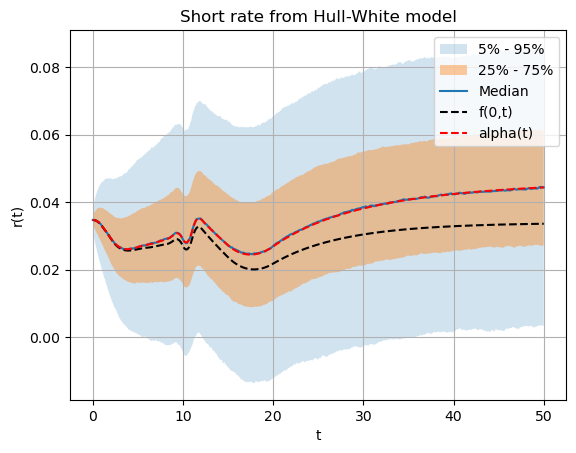

In [13]:
alpha_t = forward_rate(t) + sigma**2/(2*a**2)*(1-np.exp(-a*t))**2
percentiles = np.percentile(R, [5, 25, 50, 75, 95], axis=0)
fig, ax1 = plt.subplots(1,1)
ax1.fill_between(t, percentiles[0], percentiles[4], alpha=0.2, label="5% - 95%")
ax1.fill_between(t, percentiles[1], percentiles[3], alpha=0.4, label="25% - 75%")
ax1.plot(t, percentiles[2], label="Median")
ax1.plot(t, forward_rate(t), "--k", label="f(0,t)")
ax1.plot(t, alpha_t, "--r", label="alpha(t)")
ax1.set_xlabel("t")
ax1.set_ylabel("r(t)")
ax1.set_title("Short rate from Hull-White model")
ax1.grid()
ax1.legend()
plt.show()

<a id="8"></a> <br>
## Test 1; Term structure compared to the EIOPA published curve

The scenarios are only as good as the term structure they are built on. This test recalculates the annually compounded spot rates with the Smith & Wilson algorithm used by the generator and compares them to the spot rates published by EIOPA for maturities 1 to 150 years.

In [14]:
calculated_spot_rates = smith_wilson_extrapolate_yield_curve(published_maturities.copy(), curve_parameters["target_maturities"], curve_parameters["calibration_vector"], curve_parameters["ultimate_forward_rate"], curve_parameters["convergence_speed"])
test_statistics_bdp_1 = pd.DataFrame(abs(calculated_spot_rates - published_spot_rates)*10000, index=published_maturities, columns=["Abs diff in bps"])
test_statistics_bdp_1.head()

,Abs diff in bps
1.0,0.000002
2.0,0.044901
3.0,0.002998
4.0,0.010952
5.0,0.011644


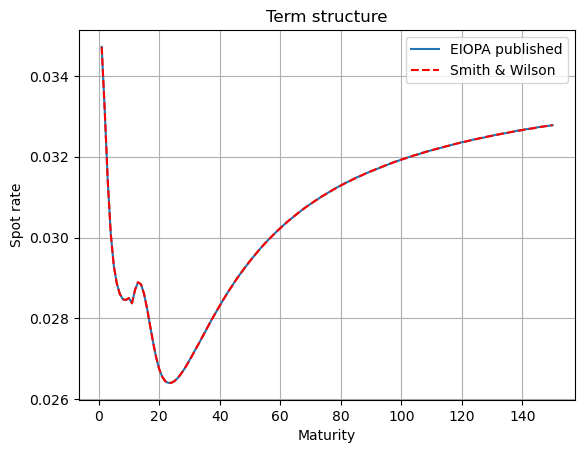

In [15]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(published_maturities, published_spot_rates, label="EIOPA published")
ax1.plot(published_maturities, calculated_spot_rates, "--r", label="Smith & Wilson")
ax1.set_xlabel("Maturity")
ax1.set_ylabel("Spot rate")
ax1.set_title("Term structure")
ax1.grid()
ax1.legend()
plt.show()

### Test 1; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [16]:
result1 = success_test(test_statistics_bdp_1.values, term_structure_max_diff_in_bps, term_structure_average_diff_in_bps)

Test passed
Test passed


<a id="9"></a> <br>
## Test 2; Deterministic checks

Some properties of the output can be checked without any Monte Carlo noise:

 - If the volatility is set to $\sigma = 0$, the short rate is deterministic and equal to the forward rate, $r(t) = f(0,t)$.
 - If the volatility is set to $\sigma = 0$, the discount factors are equal to the input term structure, $D(t) = P(0,t)$, for every path.
 - For any volatility, the bank account (output "I") is the inverse of the discount factor (output "D"), $I(t) D(t) = 1$.

The first two checks isolate the deterministic part of the model from the random part. They would detect a discretisation error in the drift of the short rate.

In [17]:
np.random.seed(seed)
paths_zero_vol = calculate_hull_white_paths(num_paths, num_steps, end_time, zero_coupon_price, a, 0.0, epsilon)

test_statistics_2 = pd.DataFrame({
    "Max abs diff of short rate (sigma = 0)": [np.max(np.abs(paths_zero_vol["R"] - forward_rate(t)))],
    "Max abs diff of discount factors (sigma = 0)": [np.max(np.abs(paths_zero_vol["M"] - implied_term_structure))],
    "Max abs diff of I * D": [np.max(np.abs(I * M - 1))]})
test_statistics_2

,Max abs diff of short rate (sigma = 0),Max abs diff of discount factors (sigma = 0),Max abs diff of I * D
0,0.0,0.0,1.110223e-16


### Test 2; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [18]:
result2 = success_test(test_statistics_2.values, numerical_precision, numerical_precision)

Test passed
Test passed


<a id="10"></a> <br>
## Test 3; Martingale test

Market consistency requires that the price of a ZCB implied by the scenarios is equal to the price given by the term structure:

$$ E\big[ D(t) \big] = P(0,t) \qquad \text{for every } t $$

The simulated average is a Monte Carlo estimate, so it is compared to $P(0,t)$ relative to its standard error:

$$ z(t) = \frac{\overline{D(t)} - P(0,t)}{\text{std}\big(D(t)\big) / \sqrt{n}} $$

Where n is the number of paths.

Note that it is the average discount factor, and not the average short rate, that reproduces the term structure. Because of the convexity of the discount factor, the average short rate $\alpha(t)$ is higher than the forward rate $f(0,t)$ (see the chart of the simulated short rate).

In [19]:
sample_mean = np.mean(M, axis=0)[1:]
standard_error = np.std(M, axis=0, ddof=1)[1:] / np.sqrt(num_paths)
z_score_3 = (sample_mean - implied_term_structure[1:]) / standard_error
test_statistics_3 = pd.DataFrame(np.abs(z_score_3), index=t[1:], columns=["Abs z-score"])
test_statistics_3.describe()

,Abs z-score
count,600.000000
mean,0.152564
std,0.107466
min,0.000005
25%,0.046737
50%,0.143008
75%,0.246827
max,0.329099


***
<span style=color:black>
    <b>Implied and simulated price of a ZCB</b>
</span>
<br>
<span style=color:black>
    Monte Carlo estimate with a band of 3 standard errors
</span>

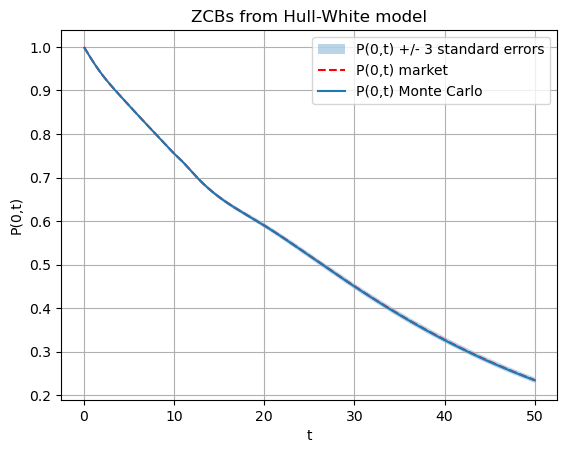

In [20]:
fig, ax1 = plt.subplots(1,1)
ax1.fill_between(t[1:], implied_term_structure[1:] - 3*standard_error, implied_term_structure[1:] + 3*standard_error, alpha=0.3, label="P(0,t) +/- 3 standard errors")
ax1.plot(t, implied_term_structure, "--r", label="P(0,t) market")
ax1.plot(t[1:], sample_mean, label="P(0,t) Monte Carlo")
ax1.set_xlabel("t")
ax1.set_ylabel("P(0,t)")
ax1.set_title("ZCBs from Hull-White model")
ax1.grid()
ax1.legend()
plt.show()

### Test 3; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [21]:
result3 = success_test(test_statistics_3.values, z_score_max, z_score_average)

Test passed
Test passed


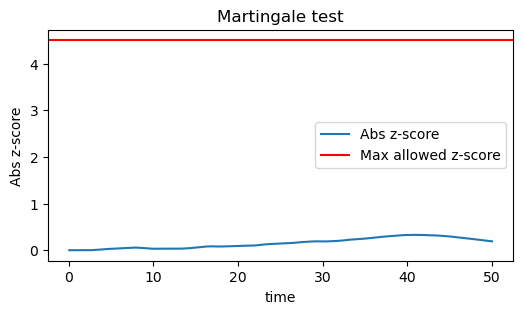

In [22]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], test_statistics_3, label= "Abs z-score")
ax1.axhline(y = z_score_max, color = 'r', linestyle = '-',label="Max allowed z-score")
ax1.set_xlabel("time")
ax1.set_ylabel("Abs z-score")
ax1.set_title('Martingale test')
ax1.legend()
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

<a id="11"></a> <br>
## Test 4; Distribution of the short rate

The Hull-White model is one of the few widely used short rate models with a closed-form distribution of the short rate. The short rate is normally distributed:

$$ r(t) \sim N\Big( \alpha(t), \; \frac{\sigma^2}{2a}\big( 1-e^{-2at} \big) \Big), \qquad \alpha(t) = f(0,t) + \frac{\sigma^2}{2a^2}\big(1 - e^{-at}\big)^2 $$

This test compares the simulated mean and variance of the short rate with these theoretical values. It checks that the parameters $a$ and $\sigma$ are correctly implemented.

Because of the moment matching of the normal draws, the simulated mean is equal to the theoretical mean up to numerical precision. The simulated variance is a Monte Carlo estimate. It is compared to the theoretical variance relative to the standard error of the sample variance of a normal distribution, $V(t) \sqrt{2/(n-1)}$.

In [23]:
theoretical_mean = alpha_t[1:]
theoretical_variance = sigma**2/(2*a)*(1-np.exp(-2*a*t[1:]))

simulated_mean = np.mean(R, axis=0)[1:]
simulated_variance = np.var(R, axis=0, ddof=1)[1:]

z_score_4 = (simulated_variance - theoretical_variance) / (theoretical_variance * np.sqrt(2 / (num_paths - 1)))
test_statistics_4_mean = pd.DataFrame(np.abs(simulated_mean - theoretical_mean), index=t[1:], columns=["Abs diff of mean"])
test_statistics_4_variance = pd.DataFrame(np.abs(z_score_4), index=t[1:], columns=["Abs z-score of variance"])
pd.concat([test_statistics_4_mean, test_statistics_4_variance], axis=1).describe()

,Abs diff of mean,Abs z-score of variance
count,6.000000e+02,600.000000
mean,7.717785e-17,0.542338
std,5.797996e-17,0.365413
min,0.000000e+00,0.005578
25%,3.122502e-17,0.235439
50%,6.245005e-17,0.497422
75%,1.144917e-16,0.796807
max,2.914335e-16,1.824386


***
<span style=color:black>
    <b>Theoretical and simulated variance of the short rate</b>
</span>
<br>
<span style=color:black>
    Visual comparison
</span>

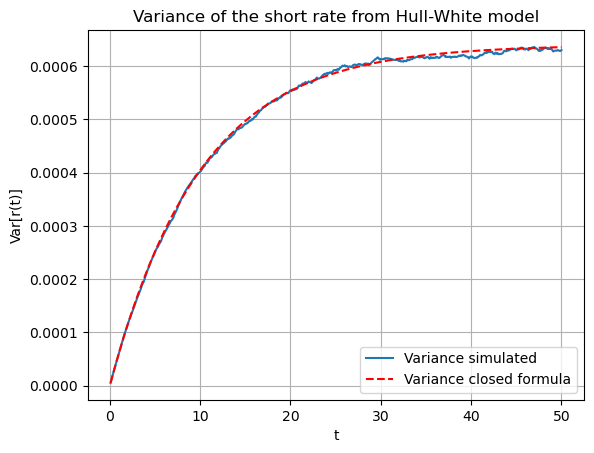

In [24]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], simulated_variance, label="Variance simulated")
ax1.plot(t[1:], theoretical_variance, "--r", label="Variance closed formula")
ax1.set_xlabel("t")
ax1.set_ylabel("Var[r(t)]")
ax1.set_title("Variance of the short rate from Hull-White model")
ax1.grid()
ax1.legend()
plt.show()

### Test 4; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [25]:
result4_mean = success_test(test_statistics_4_mean.values, numerical_precision, numerical_precision)

Test passed
Test passed


In [26]:
result4_variance = success_test(test_statistics_4_variance.values, z_score_max, z_score_average)

Test passed
Test passed


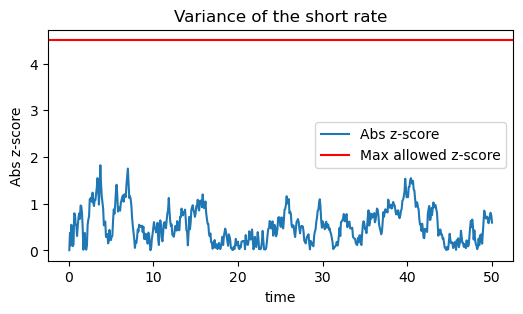

In [27]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], test_statistics_4_variance, label= "Abs z-score")
ax1.axhline(y = z_score_max, color = 'r', linestyle = '-',label="Max allowed z-score")
ax1.set_xlabel("time")
ax1.set_ylabel("Abs z-score")
ax1.set_title('Variance of the short rate')
ax1.legend()
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

<a id="12"></a> <br>
## Test 5; Prices of bonds and bond options

Tests 3 and 4 look at the discount factors and at the short rate separately. This test checks that they are consistent with each other, by pricing instruments that depend on both. In the Hull-White model, the price at time S of a ZCB maturing at time T is a closed-form function of the short rate:

$$ P(S,T) = A(S,T) e^{-B(S,T) r(S)}, \qquad B(S,T) = \frac{1 - e^{-a(T-S)}}{a}, \qquad A(S,T) = \frac{P(0,T)}{P(0,S)} \exp\Big( B(S,T) f(0,S) - \frac{\sigma^2}{4a}\big(1 - e^{-2aS}\big) B(S,T)^2 \Big) $$

**Future bond price.** Market consistency requires that the discounted future price of the bond is equal to its price today:

$$ E\big[ D(S) P(S,T) \big] = P(0,T) $$

**Bond option.** The price of a European call option with expiry S and strike K on a ZCB maturing at T has the closed-form solution:

$$ ZBC(S,T,K) = P(0,T) N(h) - K P(0,S) N(h - \sigma_p), \qquad \sigma_p = \frac{\sigma}{a}\big(1 - e^{-a(T-S)}\big) \sqrt{\frac{1 - e^{-2aS}}{2a}}, \qquad h = \frac{1}{\sigma_p} \ln \frac{P(0,T)}{P(0,S) K} + \frac{\sigma_p}{2} $$

Where N is the cumulative distribution function of the standard normal distribution. The Monte Carlo price is $E\big[ D(S) \max(P(S,T) - K, 0) \big]$. The option price depends on the whole volatility structure of the model, which makes it the strongest single check of the implementation.

The test uses expiries S of 1 to 40 years, bonds with a maturity of T = S + 10 years and at-the-money forward strikes $K = P(0,T)/P(0,S)$.

In [28]:
normal_cdf = np.vectorize(lambda x: 0.5 * (1 + math.erf(x / math.sqrt(2))))

expiry = np.arange(1, 41).astype(float)
maturity = expiry + 10
expiry_index = np.round(expiry / end_time * num_steps).astype(int)

P0S = zero_coupon_price(expiry)
P0T = zero_coupon_price(maturity)
B = (1 - np.exp(-a * (maturity - expiry))) / a
A = P0T / P0S * np.exp(B * forward_rate(expiry) - sigma**2 / (4 * a) * (1 - np.exp(-2 * a * expiry)) * B**2)
future_bond_price = A * np.exp(-B * R[:, expiry_index])
discount_to_expiry = M[:, expiry_index]

In [29]:
# Future bond price
discounted_bond = discount_to_expiry * future_bond_price
z_score_5_bond = (np.mean(discounted_bond, axis=0) - P0T) / (np.std(discounted_bond, axis=0, ddof=1) / np.sqrt(num_paths))

# Bond option
strike = P0T / P0S
sigma_p = sigma / a * (1 - np.exp(-a * (maturity - expiry))) * np.sqrt((1 - np.exp(-2 * a * expiry)) / (2 * a))
h = np.log(P0T / (P0S * strike)) / sigma_p + sigma_p / 2
option_closed_form = P0T * normal_cdf(h) - strike * P0S * normal_cdf(h - sigma_p)
discounted_payoff = discount_to_expiry * np.maximum(future_bond_price - strike, 0)
option_monte_carlo = np.mean(discounted_payoff, axis=0)
z_score_5_option = (option_monte_carlo - option_closed_form) / (np.std(discounted_payoff, axis=0, ddof=1) / np.sqrt(num_paths))

test_statistics_5_bond = pd.DataFrame(np.abs(z_score_5_bond), index=expiry, columns=["Abs z-score of bond price"])
test_statistics_5_option = pd.DataFrame(np.abs(z_score_5_option), index=expiry, columns=["Abs z-score of option price"])
pd.concat([test_statistics_5_bond, test_statistics_5_option], axis=1).describe()

,Abs z-score of bond price,Abs z-score of option price
count,40.000000,40.000000
mean,0.179623,0.351051
std,0.133546,0.288059
min,0.002890,0.037782
25%,0.067268,0.127804
50%,0.143241,0.250014
75%,0.249821,0.550613
max,0.440512,1.010585


***
<span style=color:black>
    <b>Closed-form and Monte Carlo price of a ZCB call option</b>
</span>
<br>
<span style=color:black>
    At-the-money options on a 10 year ZCB
</span>

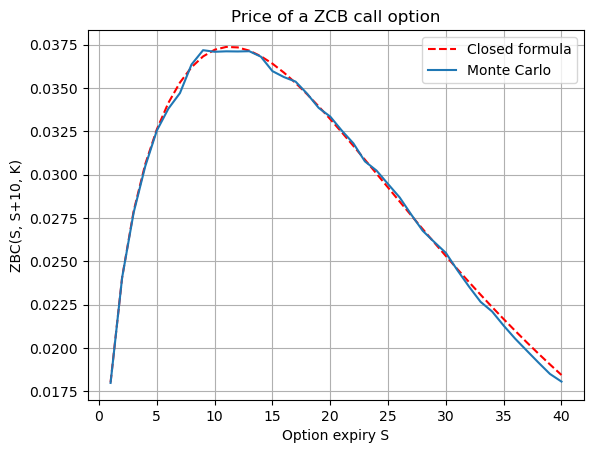

In [30]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(expiry, option_closed_form, "--r", label="Closed formula")
ax1.plot(expiry, option_monte_carlo, label="Monte Carlo")
ax1.set_xlabel("Option expiry S")
ax1.set_ylabel("ZBC(S, S+10, K)")
ax1.set_title("Price of a ZCB call option")
ax1.grid()
ax1.legend()
plt.show()

### Test 5; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [31]:
result5_bond = success_test(test_statistics_5_bond.values, z_score_max, z_score_average)

Test passed
Test passed


In [32]:
result5_option = success_test(test_statistics_5_option.values, z_score_max, z_score_average)

Test passed
Test passed


<a id="13"></a> <br>
## Number of scenarios

The z-scores in Tests 3 to 5 check that the differences are consistent with the Monte Carlo noise, but not whether the noise itself is small enough for the intended use. This section reports the size of the noise for the number of paths used in this run.

The table shows the relative standard error of the average discount factor, expressed in bps of yield ($SE / (P(0,t) \cdot t)$), and the number of paths needed so that three standard errors correspond to less than 1 bp of yield. The standard error is estimated without moment matching, so it is a conservative estimate. The moment matching reduces the actual error, which is shown in the last column for this run. This section is informative and has no success criteria.

In [33]:
selected_years = np.array([1, 5, 10, 20, 30, 40, 50])
selected_index = np.round(selected_years / end_time * num_steps).astype(int)
relative_standard_error = standard_error[selected_index - 1] / implied_term_structure[selected_index]
standard_error_in_bps_of_yield = relative_standard_error / selected_years * 10000
paths_needed = np.ceil(num_paths * (3 * standard_error_in_bps_of_yield / 1.0)**2).astype(int)
actual_difference_in_bps_of_yield = np.abs(sample_mean[selected_index - 1] / implied_term_structure[selected_index] - 1) / selected_years * 10000
pd.DataFrame({"Standard error in bps of yield": standard_error_in_bps_of_yield,
              "Paths needed for 3 SE < 1 bp": paths_needed,
              "Actual difference in bps of yield": actual_difference_in_bps_of_yield}, index=pd.Index(selected_years, name="Maturity"))

,Standard error in bps of yield,Paths needed for 3 SE < 1 bp,Actual difference in bps of yield
Maturity,,,
1,0.453661,18523,0.000120
5,0.937197,79051,0.027695
10,1.223974,134831,0.039094
20,1.494120,200916,0.139044
30,1.623772,237298,0.305817
40,1.698704,259704,0.555659
50,1.774907,283527,0.337837


<a id="14"></a> <br>
## Conclusion

The tests are successful if the Hull-White interest rate generator, built on the EIOPA term structure, passes all the success criteria. Based on the performed tests, if all the tests pass, it is likely that the implementation was generated using a correct methodology and ran using the correct parameters.

In [34]:
pd.DataFrame(data = [result1, result2, result3, result4_mean, result4_variance, result5_bond, result5_option], columns = ["Max test","Mean test"],  \
             index= ["Term structure vs EIOPA", "Deterministic checks", "Martingale test", "Mean of short rate", "Variance of short rate", "Future bond price", "Bond option price"])

,Max test,Mean test
Term structure vs EIOPA,True,True
Deterministic checks,True,True
Martingale test,True,True
Mean of short rate,True,True
Variance of short rate,True,True
Future bond price,True,True
Bond option price,True,True
